## 전이 학습 모델 - ResNet1D
- train, evaluate, evaluate_test 모두 lstm 용 사용 가능

In [45]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchinfo import summary

from dataset_multi import EEGDatasetMulti
from models import ResNet1D_EEG  # 전이학습 모델
from train_lstm import train_model  # 학습 루프
from evaluate import evaluate  # 검증 함수

import os
import random
import matplotlib.pyplot as plt

In [46]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np

def plot_confusion_matrix(cm_path, labels=["Normal", "Seizure"], save_path=None, title="Confusion Matrix", figsize=(6, 5)):
    """
    저장된 .pkl 형식의 혼동 행렬을 불러와 시각화
    - cm_path: 저장된 혼동행렬 .pkl 경로
    - labels: 축 이름
    - save_path: 저장할 이미지 경로 (None이면 저장 안 함)
    - title: 그래프 제목
    - figsize: 그래프 크기
    """
    # 혼동 행렬 불러오기
    with open(cm_path, "rb") as f:
        cm = pickle.load(f)

    # 시각화
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"혼동행렬 저장됨: {save_path}")
    plt.show()

In [48]:
# 하이퍼파라미터 설정
BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [49]:
# 데이터 로드
X_train_path = "./DATA/multi_X_train.npy"
y_train_path = "./DATA/multi_y_train.npy"
X_val_path   = "./DATA/multi_X_val.npy"
y_val_path   = "./DATA/multi_y_val.npy"

train_dataset = EEGDatasetMulti(X_train_path, y_train_path)
val_dataset   = EEGDatasetMulti(X_val_path, y_val_path)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)


In [50]:
# 모델 정의
model = ResNet1D_EEG(
    in_channels=12,
    base_filters=64,
    kernel_size=7,
    stride=2,
    n_block=4,
    n_classes=2
).to(DEVICE)

In [51]:
# 모델 구조 확인
summary(model, input_size=(64, 12, 256), device=DEVICE) 

Layer (type:depth-idx)                   Output Shape              Param #
ResNet1D_EEG                             [64, 2]                   --
├─Sequential: 1-1                        [64, 64, 128]             --
│    └─Conv1d: 2-1                       [64, 64, 128]             5,376
│    └─BatchNorm1d: 2-2                  [64, 64, 128]             128
│    └─ReLU: 2-3                         [64, 64, 128]             --
├─Sequential: 1-2                        [64, 256, 32]             --
│    └─ResidualBlock1D: 2-4              [64, 128, 64]             --
│    │    └─Sequential: 3-1              [64, 128, 64]             8,448
│    │    └─Conv1d: 3-2                  [64, 128, 64]             57,344
│    │    └─BatchNorm1d: 3-3             [64, 128, 64]             256
│    │    └─ReLU: 3-4                    [64, 128, 64]             --
│    │    └─Conv1d: 3-5                  [64, 128, 64]             114,688
│    │    └─BatchNorm1d: 3-6             [64, 128, 64]             2

In [52]:
# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [53]:
# train_model(model, train_loader, val_loader, criterion, optimizer, DEVICE, num_epochs=EPOCHS)

In [54]:
from models import CNN_LSTM_Hybrid
model2 = CNN_LSTM_Hybrid(
    num_channels=12,      # EEG 채널 수
    seq_len=256,          # 시계열 길이
    num_classes=2         # 이진 분류
).to(DEVICE)

In [55]:
# 모델 구조 확인
summary(model2, input_size=(64, 12, 256), device=DEVICE) 

Layer (type:depth-idx)                   Output Shape              Param #
CNN_LSTM_Hybrid                          [64, 2]                   --
├─Sequential: 1-1                        [64, 128, 64]             --
│    └─Conv1d: 2-1                       [64, 32, 256]             2,720
│    └─BatchNorm1d: 2-2                  [64, 32, 256]             64
│    └─ReLU: 2-3                         [64, 32, 256]             --
│    └─MaxPool1d: 2-4                    [64, 32, 128]             --
│    └─Conv1d: 2-5                       [64, 64, 128]             10,304
│    └─BatchNorm1d: 2-6                  [64, 64, 128]             128
│    └─ReLU: 2-7                         [64, 64, 128]             --
│    └─MaxPool1d: 2-8                    [64, 64, 64]              --
│    └─Conv1d: 2-9                       [64, 128, 64]             24,704
│    └─BatchNorm1d: 2-10                 [64, 128, 64]             256
│    └─ReLU: 2-11                        [64, 128, 64]             --
│ 

In [56]:
# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)

In [57]:
# train_model(model2, train_loader, val_loader, criterion, optimizer, DEVICE, num_epochs=EPOCHS)

혼동행렬 저장됨: ./saved_models/confusion_matrix.png


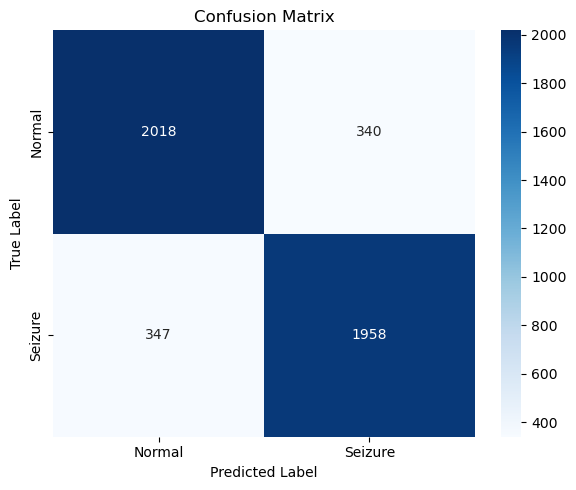

In [58]:
plot_confusion_matrix(
    cm_path="./saved_models/cm_acc_0.8527.pkl",
    save_path="./saved_models/confusion_matrix.png"
)


[Test Evaluation]
Accuracy  : 0.8379
Precision : 0.8346
Recall    : 0.8382
F1 Score  : 0.8364
Confusion Matrix:
 [[1975  383]
 [ 373 1933]]


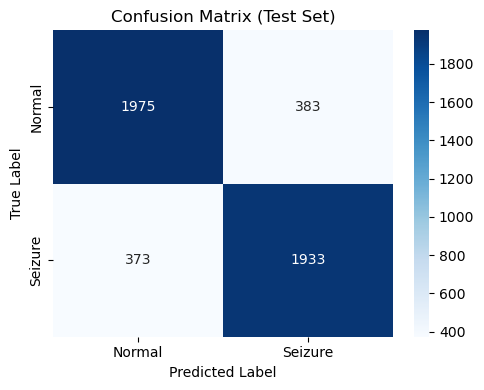

In [59]:
import torch
from torch.utils.data import DataLoader
import numpy as np
from models import CNN_LSTM_Hybrid 
from dataset_multi import EEGDatasetMulti
from evaluate_test import evaluate_on_test

# -----------------------------
# 1. 하이퍼파라미터 및 장치 설정
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
MODEL_PATH = "./saved_models/model_acc_0.8527.pt"  # ← 네가 저장한 모델 경로에 맞게 수정!

# -----------------------------
# 2. 데이터 로딩
# -----------------------------
test_dataset = EEGDatasetMulti("./DATA/multi_X_test.npy", "./DATA/multi_y_test.npy")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 3. 모델 정의 및 불러오기
# -----------------------------
model_test = CNN_LSTM_Hybrid(num_channels=12, seq_len=256, num_classes=2).to(DEVICE)
model_test.load_state_dict(torch.load(MODEL_PATH,weights_only=True))
model_test.to(DEVICE)

# -----------------------------
# 4. 평가
# -----------------------------
evaluate_on_test(model_test, test_loader, DEVICE)

추가 학습

In [60]:
# 1. 모델 불러오기
MODEL_PATH = "./saved_models/model_acc_0.8527.pt"
model = CNN_LSTM_Hybrid(num_channels=12, seq_len=256, num_classes=2).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH,weights_only=True))

# 2. Optimizer, Loss, Scheduler 설정
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [61]:
# 3. 학습 설정
start_epoch = 29  # 이전이 30 에폭까지였다고 가정
max_epochs = 100
early_stopping_patience = 15
best_val_acc = 0.8527
patience_counter = 0

In [62]:
from evaluate import evaluate
from tqdm import tqdm

# 4. 추가 학습 루프
for epoch in range(start_epoch, max_epochs + 1):
    print(f"\n[Epoch {epoch}]")
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{max_epochs}")
    for x_batch, y_batch in loop:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)

    # 🔁 여기서 evaluate 함수 호출 → 튜플로 받아서 unpack!
    val_loss, val_acc, val_prec, val_rec, val_f1, val_cm = evaluate(
        model, val_loader, criterion, DEVICE
    )

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Acc  : {val_acc:.4f}")
    print(f"Val Prec : {val_prec:.4f} | Val Rec : {val_rec:.4f} | Val F1 : {val_f1:.4f}")

    scheduler.step(val_loss)

    # Best 모델 저장
    if val_acc > best_val_acc:
        print(">> Best model updated (by accuracy)!")
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), f'./saved_models/model_acc_{val_acc:.4f}.pt')
    else:
        patience_counter += 1
        print(f">> No improvement. Patience: {patience_counter}/{early_stopping_patience}")
        
    if patience_counter >= early_stopping_patience:
        print(">> Early stopping triggered!")
        break


[Epoch 29]


Epoch 29/100: 100%|██████████| 341/341 [01:21<00:00,  4.18it/s, loss=1.21] 


Confusion Matrix:
 [[2109  249]
 [ 508 1797]]
Train Loss: 0.3234 | Val Loss: 0.3774
Val Acc  : 0.8377
Val Prec : 0.8783 | Val Rec : 0.7796 | Val F1 : 0.8260
>> No improvement. Patience: 1/15

[Epoch 30]


Epoch 30/100: 100%|██████████| 341/341 [00:58<00:00,  5.83it/s, loss=0.472]


Confusion Matrix:
 [[2137  221]
 [ 534 1771]]
Train Loss: 0.3125 | Val Loss: 0.4067
Val Acc  : 0.8381
Val Prec : 0.8891 | Val Rec : 0.7683 | Val F1 : 0.8243
>> No improvement. Patience: 2/15

[Epoch 31]


...

Confusion Matrix:
 [[2034  324]
 [ 350 1955]]
Train Loss: 0.1024 | Val Loss: 0.6253
Val Acc  : 0.8555
Val Prec : 0.8578 | Val Rec : 0.8482 | Val F1 : 0.8530
>> No improvement. Patience: 13/15

[Epoch 54]


Epoch 54/100: 100%|██████████| 341/341 [01:18<00:00,  4.36it/s, loss=0.000203]


Confusion Matrix:
 [[1900  458]
 [ 268 2037]]
Train Loss: 0.0954 | Val Loss: 0.6466
Val Acc  : 0.8443
Val Prec : 0.8164 | Val Rec : 0.8837 | Val F1 : 0.8488
>> No improvement. Patience: 14/15

[Epoch 55]


Epoch 55/100: 100%|██████████| 341/341 [01:07<00:00,  5.09it/s, loss=0.00149]


Confusion Matrix:
 [[1997  361]
 [ 357 1948]]
Train Loss: 0.0889 | Val Loss: 0.6462
Val Acc  : 0.8460
Val Prec : 0.8437 | Val Rec : 0.8451 | Val F1 : 0.8444
>> No improvement. Patience: 15/15
>> Early stopping triggered!


In [71]:
from sklearn.metrics import confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 불러오기
model = CNN_LSTM_Hybrid(num_channels=12, seq_len=256, num_classes=2).to(DEVICE)
model.load_state_dict(torch.load("./saved_models/model_acc_0.8557.pt",weights_only=True))
model.eval()

# 혼동행렬 계산
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:  # or val_loader
        x = x.to(DEVICE)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())

cm = confusion_matrix(all_targets, all_preds)

# ✅ 저장 (.pkl)
with open("./saved_models/confusion_matrix_08557.pkl", "wb") as f:
    pickle.dump(cm, f)
print("✅ 혼동행렬 저장 완료!")


✅ 혼동행렬 저장 완료!


혼동행렬 저장됨: ./saved_models/confusion_matrix_08557.png


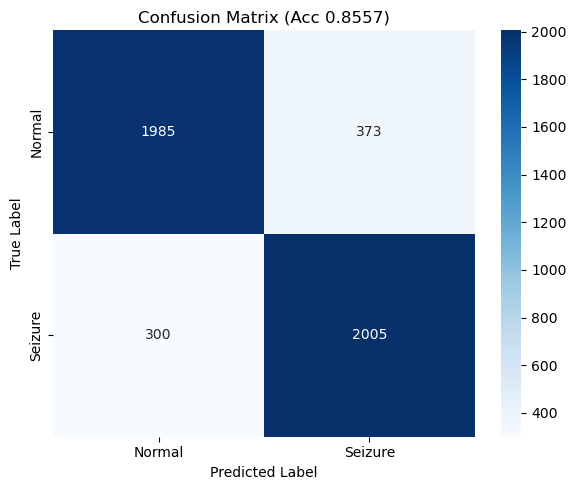

In [72]:
plot_confusion_matrix(
    cm_path="./saved_models/confusion_matrix_08557.pkl",
    labels=["Normal", "Seizure"],
    title="Confusion Matrix (Acc 0.8557)",
    save_path="./saved_models/confusion_matrix_08557.png"
)


[Test Evaluation]
Accuracy  : 0.8441
Precision : 0.8299
Recall    : 0.8612
F1 Score  : 0.8453
Confusion Matrix:
 [[1951  407]
 [ 320 1986]]


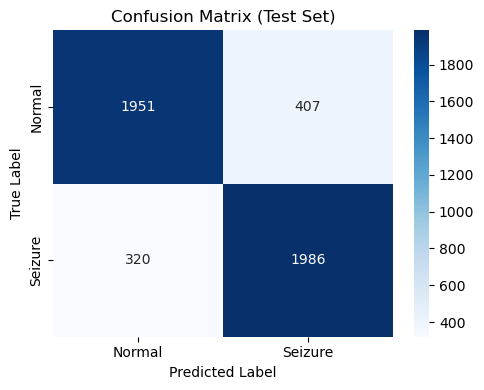

In [73]:
# -----------------------------
# 1. 하이퍼파라미터 및 장치 설정
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
MODEL_PATH = "./saved_models/model_acc_0.8557.pt"  # ← 네가 저장한 모델 경로에 맞게 수정!

# -----------------------------
# 2. 데이터 로딩
# -----------------------------
test_dataset = EEGDatasetMulti("./DATA/multi_X_test.npy", "./DATA/multi_y_test.npy")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 3. 모델 정의 및 불러오기
# -----------------------------
model_test = CNN_LSTM_Hybrid(num_channels=12, seq_len=256, num_classes=2).to(DEVICE)
model_test.load_state_dict(torch.load(MODEL_PATH,weights_only=True))
model_test.to(DEVICE)

# -----------------------------
# 4. 평가
# -----------------------------
evaluate_on_test(model_test, test_loader, DEVICE)